# Phase 8 — Efficient ViT / Hybrid-Attention Results Analysis

Joins Phase 8's local-attention results (`swin_pico_w2/w4/w8`, `swin_pico_poolmixer`,
`hybrid_bottleneck_swin`, `vit_tiny`, `deit_tiny`) plus the 3x3-conv-stem follow-up
(`vit_tiny_convstem`, `swin_pico_convstem`) to CNN reference results from Phases 1,
3, 4, and 9, and tests H1-H5 from `ideas/PHASE8_PLAN.md`.

## Validity banner — read before trusting any number below

**All 7 original Phase 8 models have results; `vit_tiny_convstem`/`swin_pico_convstem`
depend on `configs/experiments/phase8_convstem.yaml` finishing locally.** `swin_pico_w2/w4/w8`,
`swin_pico_poolmixer`, and `hybrid_bottleneck_swin` trained via
`python -m scripts.train --experiment phase8`; `vit_tiny`/`deit_tiny` trained via
`notebooks/phase_8_efficient_vit/vit_qat_phase8.ipynb` (the `DistillationTrainer` stage for
`deit_tiny`); `vit_tiny_convstem`/`swin_pico_convstem` trained via
`python -m scripts.train --experiment phase8_convstem --runtime local` (H5 follow-up: unlike
every model above, both have a genuine dense stride=1 3x3 conv in their stem -- see
`models/vit_variants.py`'s `_CONV_STEM_3X3` docstring for why none of the original 7 do).
Every load cell below is disk-driven (globs `outputs/pcad/phase8/*/results/*_summary.json`
and `outputs/local/phase8_convstem/*/results/*_summary.json`, plus the training notebook's
own output path for vit_tiny/deit_tiny) rather than a hardcoded model list, and every
hypothesis cell prints `[skip]`/`[blocked]` instead of hard-failing if a model is ever
missing again -- no notebook-structure changes needed if any Phase 8 model is retrained.

**H5's scope is narrower than `ideas/PHASE8_PLAN.md` Task 7 asks for.** `profile_kernel_trace()`
(`ml/profiling.py`) returns per-op device-time timings and a best-effort
`winograd_trace_detected` flag, but not the per-module (stem vs. attention-stage) breakdown
the plan's H5 describes — that needs new forward-hook instrumentation, out of scope for an
analysis notebook. This notebook reports whole-model latency and the per-op Winograd signal;
see Limitations at the end.


## Configuration

In [ ]:
import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


def find_project_root(start: Path | None = None) -> Path:
    """Walk upward until the repository root is found."""
    start = start or Path.cwd()
    for candidate in (start, *start.parents):
        if (candidate / "README.md").exists() and (candidate / "models").exists() and (candidate / "results").exists():
            return candidate
    return start


PROJECT_ROOT = find_project_root()
sys.path.insert(0, str(PROJECT_ROOT))  # so `import ml`/`import models` resolve regardless of kernel cwd
print(f"Project root: {PROJECT_ROOT}")

PHASE8_CLI_DIR = PROJECT_ROOT / "outputs" / "pcad" / "phase8"
PHASE8_CONVSTEM_CLI_DIR = PROJECT_ROOT / "outputs" / "local" / "phase8_convstem"
PHASE8_NOTEBOOK_RESULTS = PROJECT_ROOT / "results" / "phase_8_efficient_vit_hybrid_attention_training" / "experiment_summary.json"
PHASE8_NOTEBOOK_CKPT_DIR = PROJECT_ROOT / "checkpoints" / "phase_8_efficient_vit_hybrid_attention_training"
CROSS_PHASE_CSV = PROJECT_ROOT / "results" / "results_aggregate" / "model_details_cross_phase.csv"
PHASE4_FINAL_CSV = PROJECT_ROOT / "results" / "phase_4_compression_and_final_architecture_training" / "final_comparison.csv"
PHASE9_FIRE_BYPASS_SUMMARY = (PROJECT_ROOT / "outputs" / "pcad" / "phase_9_bypass_ablation" /
                               "fire_bypass_large_scale" / "alexnet_fire_bypass" / "results" /
                               "alexnet_fire_bypass_summary.json")
RESULTS_DIR = PROJECT_ROOT / "results" / "phase_8_efficient_vit_hybrid_attention_analysis"
FIGURES_DIR = PROJECT_ROOT / "results" / "figures_generated" / "phase_8_efficient_vit_hybrid_attention"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

from ml.plotting import apply_report_style, PALETTE, STAGE_COLORS
apply_report_style(palette=PALETTE)

SWIN_SWEEP_ORDER = ["swin_pico_w2", "swin_pico_w4", "swin_pico_w8"]
# vit_tiny_convstem/swin_pico_convstem (H5 follow-up, 3x3-restricted conv stem ahead of
# attention -- see models/vit_variants.py) trained locally via
# configs/experiments/phase8_convstem.yaml, not part of the original 7-model H1-H5 sweep.
PHASE8_MODEL_ORDER = ["swin_pico_w2", "swin_pico_w4", "swin_pico_w8",
                      "swin_pico_poolmixer", "hybrid_bottleneck_swin",
                      "vit_tiny", "deit_tiny",
                      "vit_tiny_convstem", "swin_pico_convstem"]
PHASE8_COLORS = {
    "swin_pico_w2": "#8ecae6", "swin_pico_w4": "#4a9fd4", "swin_pico_w8": "#1b6ca8",
    "swin_pico_poolmixer": "#9c89b8", "hybrid_bottleneck_swin": "#eb6834",
    "vit_tiny": "#2a9d8f", "deit_tiny": "#e76f51",
    "vit_tiny_convstem": "#264653", "swin_pico_convstem": "#e9c46a",
}
CNN_COLOR = "#6c757d"


## Load Phase 8 Results

CLI-trained models (`swin_pico_*`, `hybrid_bottleneck_swin`) each write
`outputs/pcad/phase8/{model}/results/{model}_summary.json`; `vit_tiny_convstem`/
`swin_pico_convstem` write the same flat schema under
`outputs/local/phase8_convstem/{model}/results/{model}_summary.json` instead (trained
locally, not on PCAD) — both load through the same `load_cli_summaries()`
(`ml/reporting.py`'s `make_run_summary()` schema, one flat dict per model, same shape
every prior phase uses). `vit_tiny`/`deit_tiny` come from the training notebook's
`create_results_summary()` output instead
(`results/phase_8_efficient_vit_hybrid_attention_training/experiment_summary.json`),
a *nested* `{"fp32_metrics": {...}, "int8_metrics": {...}, ...}` shape — flattened into the
same per-model row schema here so all sources merge into one DataFrame.

In [ ]:
def load_cli_summaries(cli_dir: Path) -> list[dict]:
    rows = []
    for summary_path in sorted(cli_dir.glob("*/results/*_summary.json")):
        rows.append(json.loads(summary_path.read_text()))
    return rows


def load_notebook_summary(summary_path: Path, ckpt_dir: Path) -> list[dict]:
    """Flatten vit_qat_phase8.ipynb's experiment_summary.json (Section 10) into
    per-model rows matching ml.reporting.make_run_summary()'s flat schema. Falls back to
    per-model params/size from disk (checkpoint sizes, param count) so this stays usable
    even if a field the CLI schema has isn't present in the notebook's summary.
    """
    if not summary_path.exists():
        return []
    raw = json.loads(summary_path.read_text())
    fp32_metrics = raw.get("fp32_metrics", {})
    int8_metrics = raw.get("int8_metrics", {})
    fp32_training = raw.get("fp32_training_results", {})

    rows = []
    for name in ("vit_tiny", "deit_tiny"):
        if name not in fp32_metrics or name not in int8_metrics:
            continue
        fp32_best = ckpt_dir / f"{name}_best.pth"
        int8_best = ckpt_dir / f"{name}.pth"
        fp32_size_mb = fp32_best.stat().st_size / 1e6 if fp32_best.exists() else None
        int8_size_mb = int8_best.stat().st_size / 1e6 if int8_best.exists() else None
        rows.append({
            "model_name": name,
            "fp32_top1": fp32_metrics[name].get("top1"),
            "fp32_top5": fp32_metrics[name].get("top5"),
            "fp32_loss": fp32_metrics[name].get("loss"),
            "int8_top1": int8_metrics[name].get("top1"),
            "int8_top5": int8_metrics[name].get("top5"),
            "int8_loss": int8_metrics[name].get("loss"),
            "quantization_drop_top1": fp32_metrics[name].get("top1", np.nan) - int8_metrics[name].get("top1", np.nan),
            "fp32_size_mb": fp32_size_mb,
            "int8_size_mb": int8_size_mb,
            "best_val_top1": fp32_training.get(name, {}).get("best_val_accuracy"),
            "epochs": len(fp32_training.get(name, {}).get("history", {}).get("train_loss", [])) or None,
        })
    return rows


rows = (load_cli_summaries(PHASE8_CLI_DIR) + load_cli_summaries(PHASE8_CONVSTEM_CLI_DIR)
        + load_notebook_summary(PHASE8_NOTEBOOK_RESULTS, PHASE8_NOTEBOOK_CKPT_DIR))
phase8_df = pd.DataFrame(rows)

if phase8_df.empty:
    print("[skip] No Phase 8 results found on disk yet.")
else:
    phase8_df = phase8_df.set_index("model_name")
    n_total = len(PHASE8_MODEL_ORDER)
    present = [m for m in PHASE8_MODEL_ORDER if m in phase8_df.index]
    missing = [m for m in PHASE8_MODEL_ORDER if m not in phase8_df.index]
    print(f"Present ({len(present)}/{n_total}): {present}")
    if missing:
        print(f"Missing ({len(missing)}/{n_total}): {missing} -- not trained yet, see validity banner above.")


### Run Inventory

In [15]:
if phase8_df.empty:
    print("[skip] Nothing to show.")
else:
    display_cols = [c for c in ["fp32_top1", "int8_top1", "quantization_drop_top1",
                                 "params_m", "fp32_size_mb", "int8_size_mb", "epochs"]
                     if c in phase8_df.columns]
    print(phase8_df.loc[[m for m in PHASE8_MODEL_ORDER if m in phase8_df.index], display_cols].to_string())


                        fp32_top1  int8_top1  quantization_drop_top1  params_m  fp32_size_mb  int8_size_mb  epochs
model_name                                                                                                        
swin_pico_w2            30.641368  33.253288               -2.611920  0.321188      3.755274      0.668609      99
swin_pico_w4            31.268662  33.885661               -2.616999  0.321668      3.768091      0.677764      99
swin_pico_w8            33.030838  36.991832               -3.960994  0.323780      3.909449      0.803069      99
swin_pico_poolmixer     28.211576  30.759650               -2.548075  0.227768      2.662607      0.304627      99
hybrid_bottleneck_swin  33.638141  40.177366               -6.539226  0.267824      3.137369      0.541750      99
vit_tiny                40.345603  42.440718               -2.095115       NaN     33.200842      5.658130     125
deit_tiny               46.384123  47.661337               -1.277214       NaN  

## Load CNN Comparison Data (Phases 1, 3, 4, 9)

`alexnet_bottleneck`/`alexnet_fire` are Phase 3's compensation Pareto-optimal picks
(`ideas/BEST_MODELS.md`); `vgg_style` is the closest FP32-size match to `vit_tiny` in the
whole project (medium-priority improvement #6, `ideas/PHASE8_PLAN.md`) and the strongest
pure-CNN baseline, not just the smallest one; `alexnet_tv` is the large-kernel reference
every kernel-restriction phase normalizes against. Three more references round out the
picture: `mobilenetv2` (Phase 1, ~58% FP32 -- the best model in the whole project, though
it has no INT8 stage since it's a pretrained baseline never run through QAT, so it's
excluded from the INT8-only H2/H3 comparisons below); `alexnet_final_fire_residual`
(Phase 4, 49.79% FP32 -- the best AlexNet-family hybrid, from
`results/phase_4_compression_and_final_architecture_training/final_comparison.csv`, a
long-format model/precision table pivoted into one row here); and `alexnet_fire_bypass`
(Phase 9, 49.03% FP32 with zero added parameters over `alexnet_fire`, from its own
`*_summary.json`, same flat schema Phase 8's CLI summaries use).

In [16]:
CNN_REFERENCE_MODELS = ["alexnet_bottleneck", "alexnet_fire", "alexnet_depthwisesep", "vgg_style", "alexnet_tv", "mobilenetv2"]


def load_phase4_final_row(csv_path: Path, model: str) -> dict | None:
    """final_comparison.csv is long-format (one row per model+precision, e.g.
    'alexnet_final_fire_residual' / 'alexnet_final_fire_residual_INT8') rather than Phase
    1-3's wide per-model schema -- pivot the FP32/INT8 pair into one row matching cnn_df."""
    if not csv_path.exists():
        return None
    df = pd.read_csv(csv_path)
    fp32_rows = df[df["model"] == model]
    int8_rows = df[df["model"] == f"{model}_INT8"]
    if fp32_rows.empty or int8_rows.empty:
        return None
    fp32, int8 = fp32_rows.iloc[0], int8_rows.iloc[0]
    return {
        "model_name": model, "phase": "Phase 4 — Final Architecture",
        "fp32_top1": fp32["top1_%"], "int8_top1": int8["top1_%"],
        "quantization_drop_top1": fp32["top1_%"] - int8["top1_%"],
        "fp32_size_mb": fp32["size_MB"], "int8_size_mb": int8["size_MB"],
        "params_m": fp32["params_M"],
    }


def load_phase9_summary_row(json_path: Path) -> dict | None:
    """Phase 9's alexnet_fire_bypass summary already uses ml.reporting.make_run_summary()'s
    flat schema, same as Phase 8's CLI summaries -- no pivoting needed."""
    if not json_path.exists():
        return None
    row = json.loads(json_path.read_text())
    row["phase"] = "Phase 9 — Bypass Ablation"
    return row


extra_rows = [r for r in [
    load_phase4_final_row(PHASE4_FINAL_CSV, "alexnet_final_fire_residual"),
    load_phase9_summary_row(PHASE9_FIRE_BYPASS_SUMMARY),
] if r is not None]
extra_df = pd.DataFrame(extra_rows).set_index("model_name") if extra_rows else pd.DataFrame()

if CROSS_PHASE_CSV.exists():
    cross_df = pd.read_csv(CROSS_PHASE_CSV)
    name_col = "model_name" if "model_name" in cross_df.columns else "model"
    cnn_df = cross_df[cross_df[name_col].isin(CNN_REFERENCE_MODELS)].copy()
    # some models recur across phases (e.g. alexnet_tv in Phase 1 + Phase 2) -- keep the
    # earliest/canonical phase row so later merges stay one-to-one, same convention as
    # notebooks/phase_7_detection_segmentation_analysis/phase7_results_analysis.ipynb
    cnn_df = cnn_df.sort_values("phase").drop_duplicates(subset=name_col, keep="first").set_index(name_col)
    cnn_df = pd.concat([cnn_df, extra_df])
    print(f"CNN reference models loaded: {list(cnn_df.index)}")
else:
    print(f"[skip] {CROSS_PHASE_CSV} not found")
    cnn_df = extra_df


CNN reference models loaded: ['alexnet_tv', 'mobilenetv2', 'vgg_style', 'alexnet_bottleneck', 'alexnet_depthwisesep', 'alexnet_fire', 'alexnet_final_fire_residual', 'alexnet_fire_bypass']


## H1 — Local-Attention Window Size Is the Conv-Kernel-Size Analogue

**Claim** (`ideas/PHASE8_PLAN.md`): FP32 top-1 increases monotonically with `window_size`
in `{2, 4, 8}`, reproducing Phase 2's kernel-restriction curve in attention terms.

              fp32_top1  int8_top1  window_size
model_name                                     
swin_pico_w2  30.641368  33.253288            2
swin_pico_w4  31.268662  33.885661            4
swin_pico_w8  33.030838  36.991832            8

FP32 monotonic in window_size: True
INT8 monotonic in window_size: True


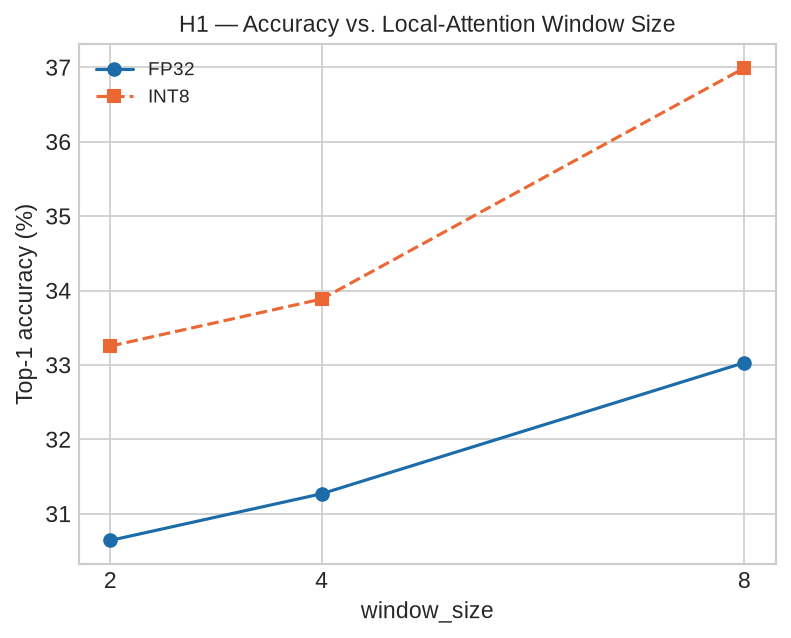

In [17]:
h1_models = [m for m in SWIN_SWEEP_ORDER if m in phase8_df.index]

if len(h1_models) < 2:
    print(f"[skip] Need at least 2 of {SWIN_SWEEP_ORDER}, have {h1_models}.")
else:
    window_sizes = {"swin_pico_w2": 2, "swin_pico_w4": 4, "swin_pico_w8": 8}
    h1_df = phase8_df.loc[h1_models, ["fp32_top1", "int8_top1"]].copy()
    h1_df["window_size"] = [window_sizes[m] for m in h1_df.index]
    h1_df = h1_df.sort_values("window_size")
    print(h1_df.to_string())

    is_monotonic_fp32 = h1_df["fp32_top1"].is_monotonic_increasing
    is_monotonic_int8 = h1_df["int8_top1"].is_monotonic_increasing
    print(f"\nFP32 monotonic in window_size: {is_monotonic_fp32}")
    print(f"INT8 monotonic in window_size: {is_monotonic_int8}")
    if len(h1_models) < 3:
        print(f"NOTE: only {len(h1_models)}/3 sweep points present -- trend is provisional.")

    fig, ax = plt.subplots(figsize=(6, 4.5))
    ax.plot(h1_df["window_size"], h1_df["fp32_top1"], "o-", label="FP32", color=STAGE_COLORS["fp32"])
    ax.plot(h1_df["window_size"], h1_df["int8_top1"], "s--", label="INT8", color=STAGE_COLORS["int8"])
    ax.set_xlabel("window_size")
    ax.set_ylabel("Top-1 accuracy (%)")
    ax.set_xticks(h1_df["window_size"])
    ax.set_title("H1 — Accuracy vs. Local-Attention Window Size")
    ax.legend()
    fig.savefig(FIGURES_DIR / "phase8_h1_window_size_sweep.png")
    plt.show()


## H2 — CNN-Stem + Attention Hybrid vs. Pure CNN / Pure Swin

**Claim**: `hybrid_bottleneck_swin` (H2, CNN stem for local texture + Swin body for
longer-range mixing) beats both pure-CNN reference architectures
(`alexnet_bottleneck`/`alexnet_fire`, Phase 3's Pareto picks, plus Phase 4/9's stronger
`alexnet_final_fire_residual`/`alexnet_fire_bypass`) and a pure-Swin model (`swin_pico_w8`,
the least window-restricted sweep point) at comparable size — same accuracy-vs-size Pareto
framing `ideas/BEST_MODELS.md` already uses for Phase 3/4.

                      model    family  int8_top1  int8_size_mb
         alexnet_bottleneck       CNN  44.539082      0.431780
               alexnet_fire       CNN  44.303995      0.551374
                  vgg_style       CNN  51.188743      2.376703
alexnet_final_fire_residual       CNN  49.201027      0.746309
        alexnet_fire_bypass       CNN  49.864638      0.554306
               swin_pico_w8 attention  36.991832      0.803069
     hybrid_bottleneck_swin    hybrid  40.177366      0.541750

Hybrid vs. pure-Swin (w8): 40.18% vs. 36.99% (+3.19pp)
Hybrid vs. best pure-CNN (alexnet_final_fire_residual): 40.18% vs. 49.20% (-9.02pp)


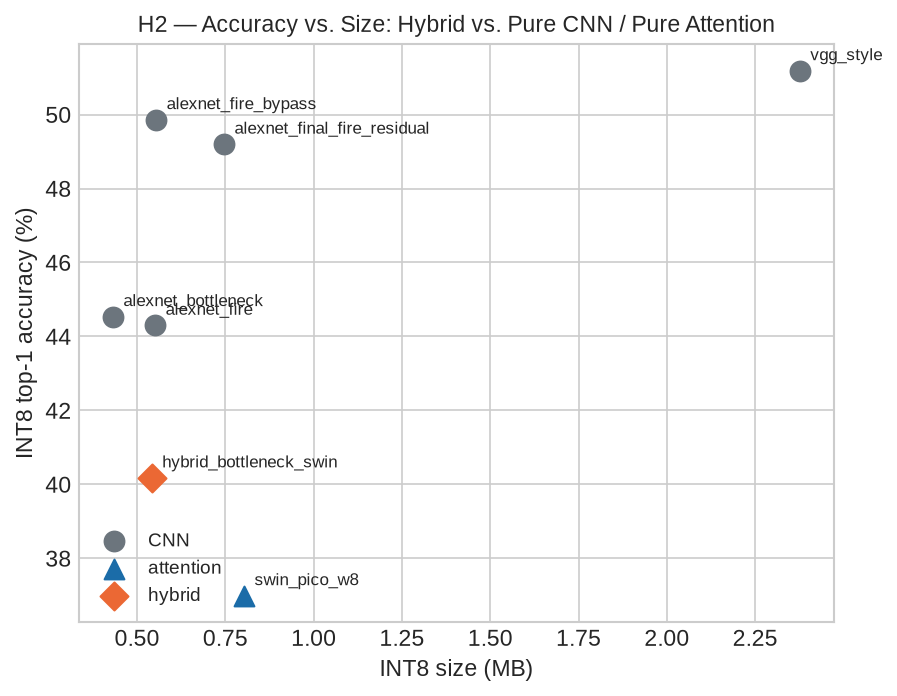

In [18]:
h2_rows = []
for name in ["alexnet_bottleneck", "alexnet_fire", "vgg_style", "alexnet_final_fire_residual", "alexnet_fire_bypass"]:
    if name in cnn_df.index and pd.notna(cnn_df.loc[name, "int8_top1"]):
        h2_rows.append({"model": name, "family": "CNN", "int8_top1": cnn_df.loc[name, "int8_top1"],
                         "int8_size_mb": cnn_df.loc[name, "int8_size_mb"]})
for name in ["swin_pico_w8", "hybrid_bottleneck_swin"]:
    if name in phase8_df.index:
        h2_rows.append({"model": name, "family": "attention" if name != "hybrid_bottleneck_swin" else "hybrid",
                         "int8_top1": phase8_df.loc[name, "int8_top1"],
                         "int8_size_mb": phase8_df.loc[name, "int8_size_mb"]})

if len(h2_rows) < 2:
    print("[skip] Not enough of {alexnet_bottleneck, alexnet_fire, vgg_style, "
          "alexnet_final_fire_residual, alexnet_fire_bypass, swin_pico_w8, "
          "hybrid_bottleneck_swin} present yet.")
else:
    h2_df = pd.DataFrame(h2_rows)
    print(h2_df.to_string(index=False))

    if "hybrid_bottleneck_swin" in h2_df["model"].values and "swin_pico_w8" in h2_df["model"].values:
        hybrid_top1 = h2_df.loc[h2_df["model"] == "hybrid_bottleneck_swin", "int8_top1"].iloc[0]
        pure_swin_top1 = h2_df.loc[h2_df["model"] == "swin_pico_w8", "int8_top1"].iloc[0]
        print(f"\nHybrid vs. pure-Swin (w8): {hybrid_top1:.2f}% vs. {pure_swin_top1:.2f}% "
              f"({'+' if hybrid_top1 >= pure_swin_top1 else ''}{hybrid_top1 - pure_swin_top1:.2f}pp)")
    if "hybrid_bottleneck_swin" in h2_df["model"].values and "alexnet_final_fire_residual" in h2_df["model"].values:
        hybrid_top1 = h2_df.loc[h2_df["model"] == "hybrid_bottleneck_swin", "int8_top1"].iloc[0]
        best_cnn_top1 = h2_df.loc[h2_df["model"] == "alexnet_final_fire_residual", "int8_top1"].iloc[0]
        print(f"Hybrid vs. best pure-CNN (alexnet_final_fire_residual): {hybrid_top1:.2f}% vs. "
              f"{best_cnn_top1:.2f}% ({'+' if hybrid_top1 >= best_cnn_top1 else ''}{hybrid_top1 - best_cnn_top1:.2f}pp)")

    fig, ax = plt.subplots(figsize=(6.5, 5))
    family_markers = {"CNN": "o", "attention": "^", "hybrid": "D"}
    for family, group in h2_df.groupby("family"):
        color = CNN_COLOR if family == "CNN" else PHASE8_COLORS.get(group["model"].iloc[0], "#333333")
        ax.scatter(group["int8_size_mb"], group["int8_top1"], marker=family_markers[family],
                   s=90, label=family, color=color if family != "CNN" else CNN_COLOR)
    for _, r in h2_df.iterrows():
        ax.annotate(r["model"], (r["int8_size_mb"], r["int8_top1"]), fontsize=8,
                   xytext=(5, 5), textcoords="offset points")
    ax.set_xlabel("INT8 size (MB)")
    ax.set_ylabel("INT8 top-1 accuracy (%)")
    ax.set_title("H2 — Accuracy vs. Size: Hybrid vs. Pure CNN / Pure Attention")
    ax.legend()
    fig.savefig(FIGURES_DIR / "phase8_h2_hybrid_pareto.png")
    plt.show()


## H3 — Quantization Robustness vs. CNN Reference Models

INT8/FP32 size ratio and quantization top-1 delta, all present Phase 8 models vs. four CNN
references: Phase 3's quantization-stable picks `alexnet_bottleneck`/`alexnet_fire`, plus
Phase 4/9's stronger-accuracy hybrids `alexnet_final_fire_residual`/`alexnet_fire_bypass`
(`ideas/BEST_MODELS.md`). This is model-size ratio, not the weights-only /
optimizer-state-excluded quantity `ideas/PHASE8_PLAN.md` H3 asks for -- see Limitations.

                              family  size_ratio  quant_drop_top1
model                                                            
alexnet_bottleneck               CNN    0.096127         0.083897
alexnet_fire                     CNN    0.092058        -0.327522
alexnet_final_fire_residual      CNN    0.092209         0.592265
alexnet_fire_bypass              CNN    0.092531        -0.838107
hybrid_bottleneck_swin       Phase 8    0.172677        -6.539226
swin_pico_poolmixer          Phase 8    0.114409        -2.548075
swin_pico_w2                 Phase 8    0.178045        -2.611920
swin_pico_w4                 Phase 8    0.179869        -2.616999
swin_pico_w8                 Phase 8    0.205417        -3.960994
vit_tiny                     Phase 8    0.170421        -2.095115
deit_tiny                    Phase 8    0.170425        -1.277214


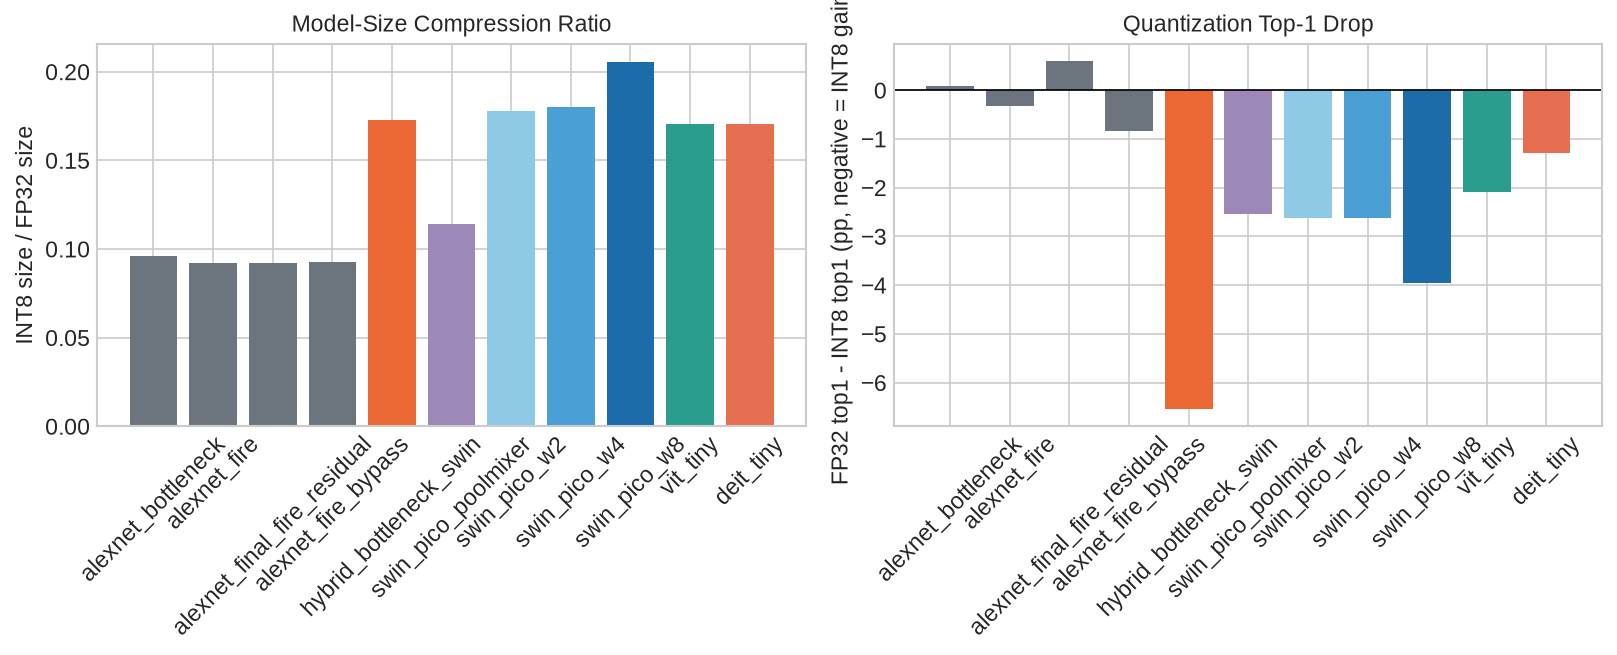

In [19]:
h3_rows = []
h3_cnn_models = ("alexnet_bottleneck", "alexnet_fire", "alexnet_final_fire_residual", "alexnet_fire_bypass")
for name in cnn_df.index:
    if name in h3_cnn_models and pd.notna(cnn_df.loc[name, "int8_size_mb"]) and pd.notna(cnn_df.loc[name, "fp32_size_mb"]):
        h3_rows.append({"model": name, "family": "CNN",
                         "size_ratio": cnn_df.loc[name, "int8_size_mb"] / cnn_df.loc[name, "fp32_size_mb"],
                         "quant_drop_top1": cnn_df.loc[name, "quantization_drop_top1"]})
for name in phase8_df.index:
    if pd.notna(phase8_df.loc[name].get("fp32_size_mb")) and pd.notna(phase8_df.loc[name].get("int8_size_mb")):
        h3_rows.append({"model": name, "family": "Phase 8",
                         "size_ratio": phase8_df.loc[name, "int8_size_mb"] / phase8_df.loc[name, "fp32_size_mb"],
                         "quant_drop_top1": phase8_df.loc[name].get("quantization_drop_top1")})

if len(h3_rows) < 2:
    print("[skip] Not enough models with both FP32 and INT8 size on disk yet.")
else:
    h3_df = pd.DataFrame(h3_rows).set_index("model")
    print(h3_df.to_string())

    fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
    colors = [CNN_COLOR if f == "CNN" else PHASE8_COLORS.get(m, "#333333") for m, f in zip(h3_df.index, h3_df["family"])]
    axes[0].bar(h3_df.index, h3_df["size_ratio"], color=colors)
    axes[0].set_ylabel("INT8 size / FP32 size")
    axes[0].set_title("Model-Size Compression Ratio")
    axes[0].tick_params(axis="x", rotation=45)
    axes[1].bar(h3_df.index, h3_df["quant_drop_top1"], color=colors)
    axes[1].axhline(0, color="black", linewidth=0.8)
    axes[1].set_ylabel("FP32 top1 - INT8 top1 (pp, negative = INT8 gain)")
    axes[1].set_title("Quantization Top-1 Drop")
    axes[1].tick_params(axis="x", rotation=45)
    fig.tight_layout()
    fig.savefig(FIGURES_DIR / "phase8_h3_quantization_robustness.png")
    plt.show()


## H4 — Does Distillation Help? `vit_tiny` vs. `deit_tiny`

Same architecture and hyperparameters (`deit_tiny = vit_tiny` in `models/vit_variants.py`);
only the training loop differs (`DistillationTrainer`, hard-label distillation from a frozen
`mobilenetv2` teacher, Touvron et al. 2021).

            fp32_top1  int8_top1
model_name                      
vit_tiny    40.345603  42.440718
deit_tiny   46.384123  47.661337

Distillation effect (FP32 top1, deit - vit): +6.04pp


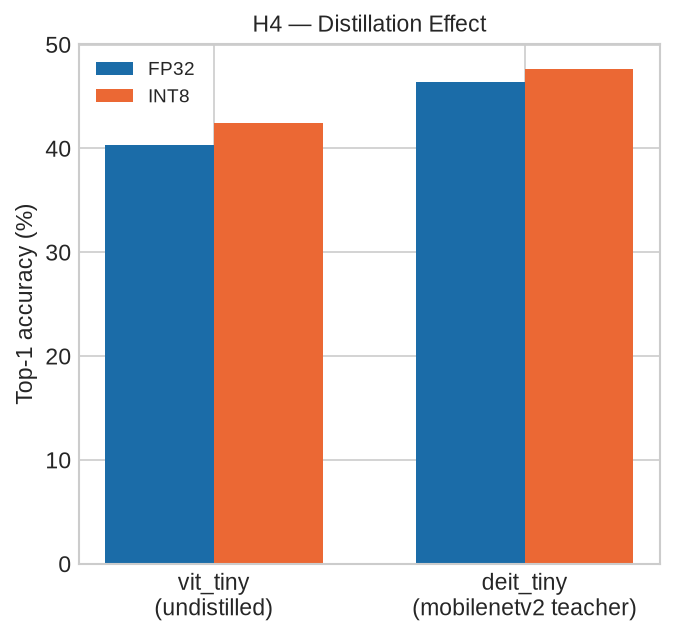

In [20]:
h4_models = [m for m in ("vit_tiny", "deit_tiny") if m in phase8_df.index]

if len(h4_models) < 2:
    print(f"[blocked] Need both vit_tiny and deit_tiny; have {h4_models}. "
          "Run notebooks/phase_8_efficient_vit/vit_qat_phase8.ipynb "
          "then re-run this cell.")
else:
    h4_df = phase8_df.loc[["vit_tiny", "deit_tiny"], ["fp32_top1", "int8_top1"]]
    print(h4_df.to_string())
    delta = h4_df.loc["deit_tiny", "fp32_top1"] - h4_df.loc["vit_tiny", "fp32_top1"]
    print(f"\nDistillation effect (FP32 top1, deit - vit): {delta:+.2f}pp")

    fig, ax = plt.subplots(figsize=(5, 4.5))
    x = np.arange(2)
    width = 0.35
    ax.bar(x - width / 2, h4_df["fp32_top1"], width, label="FP32", color=STAGE_COLORS["fp32"])
    ax.bar(x + width / 2, h4_df["int8_top1"], width, label="INT8", color=STAGE_COLORS["int8"])
    ax.set_xticks(x)
    ax.set_xticklabels(["vit_tiny\n(undistilled)", "deit_tiny\n(mobilenetv2 teacher)"])
    ax.set_ylabel("Top-1 accuracy (%)")
    ax.set_title("H4 — Distillation Effect")
    ax.legend()
    fig.savefig(FIGURES_DIR / "phase8_h4_distillation.png")
    plt.show()


## H5 — Winograd Eligibility: Does Attention Dilute Dense-Kernel Structure?

**Claim**: attention-heavy models spend less device time in Winograd-eligible convolution
than a comparable-depth pure-CNN model. Live-profiled on whichever device is available
locally (GPU preferred; `ideas/PHASE8_PLAN.md`'s "full PCAD sweep is a stretch goal" applies
here the same way it did for Phase 6/7). Model constructors are imported directly (not
loaded from checkpoint) since H5 only needs architecture, not trained weights.

In [21]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Profiling device: {device}")
if device.type != "cuda":
    print("NOTE: no CUDA device available -- Winograd kernel selection is a cuDNN/GPU "
          "concept, so op-timing/kernel-name results on CPU are not meaningful for this "
          "hypothesis. Latency numbers below are still valid as a CPU reference point.")


Profiling device: cuda


In [ ]:
from ml.profiling import profile_model_latency, profile_kernel_trace
from models.vit_variants import (
    vit_tiny, swin_pico_w2, swin_pico_w4, swin_pico_w8, swin_pico_poolmixer,
    hybrid_bottleneck_swin, vit_tiny_convstem, swin_pico_convstem,
)

H5_CONSTRUCTORS = {
    "swin_pico_w2": swin_pico_w2, "swin_pico_w4": swin_pico_w4, "swin_pico_w8": swin_pico_w8,
    "swin_pico_poolmixer": swin_pico_poolmixer, "hybrid_bottleneck_swin": hybrid_bottleneck_swin,
    "vit_tiny": vit_tiny, "deit_tiny": vit_tiny,  # deit_tiny shares vit_tiny's constructor
    # 3x3-restricted conv stem (a genuine dense stride=1 groups=1 conv, unlike every model
    # above) ahead of attention -- this is the actual test of whether an attention model
    # can trigger F(2x2,3x3) at all.
    "vit_tiny_convstem": vit_tiny_convstem, "swin_pico_convstem": swin_pico_convstem,
}
IMG_SIZE = 64
INPUT_SIZE = (1, 3, IMG_SIZE, IMG_SIZE)

h5_rows = []
for name, ctor in H5_CONSTRUCTORS.items():
    model = ctor(num_classes=200)
    latency_ms = profile_model_latency(model, INPUT_SIZE, device, warmup=20, iters=100)
    trace = profile_kernel_trace(model, torch.randn(INPUT_SIZE), device)
    h5_rows.append({
        "model": name,
        "latency_ms": latency_ms,
        "winograd_trace_detected": trace["winograd_trace_detected"],
        "top_cuda_kernel": trace["top_cuda_kernel"],
    })
    del model

h5_df = pd.DataFrame(h5_rows).set_index("model")
# Persisted so the report's Eixo 7 claim ("no Winograd trace in any of the seven") is
# auditable without rerunning this cell -- it was prose-only before.
h5_df.assign(
    device=torch.cuda.get_device_name(0) if device.type == "cuda" else "cpu",
    torch_version=torch.__version__,
    cudnn_version=torch.backends.cudnn.version(),
).to_csv(RESULTS_DIR / "phase8_h5_winograd_trace.csv")
print(h5_df.to_string())
print("\nCaveat (ml/profiling.py's profile_kernel_trace docstring): cuDNN's Winograd kernel "
      "naming is not stable across versions, so winograd_trace_detected=False is weak "
      "evidence of absence, not proof. Report top_cuda_kernel alongside the flag.")


CNN reference latency (pre-recorded, NOT the same device as the live Phase 8 numbers above unless this notebook is also running on that hardware; compare shapes/trends, not absolute ms). alexnet_final_fire_residual has no recorded latency (final_comparison.csv doesn't carry it):
                     latency_ms
model_name                     
alexnet_bottleneck     0.105113
alexnet_fire           0.150724
alexnet_fire_bypass    0.200522


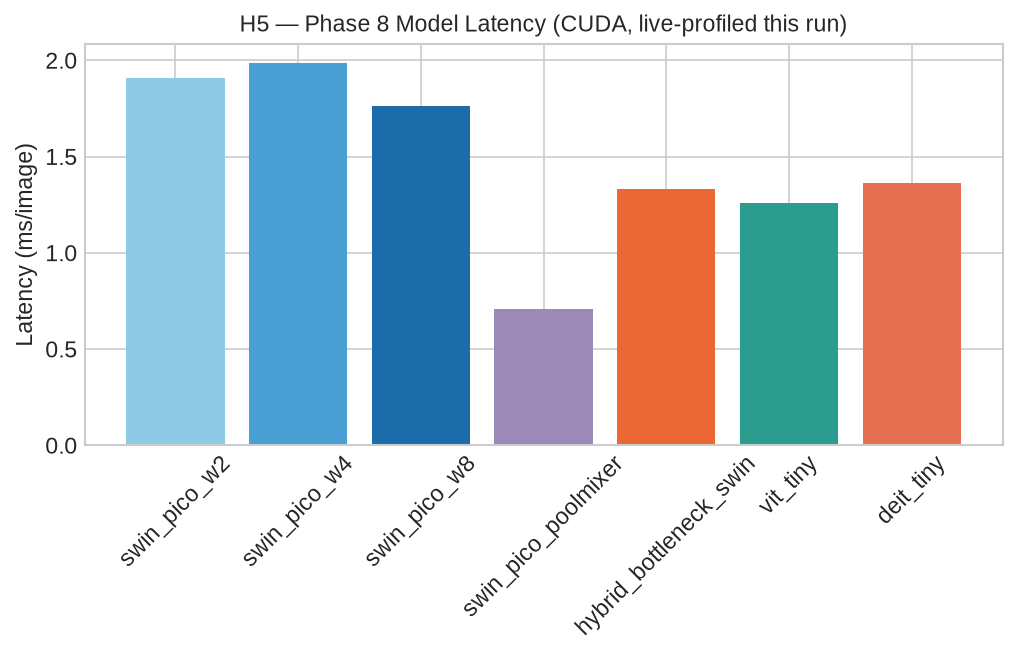

In [23]:
cnn_latency_models = [m for m in ["alexnet_bottleneck", "alexnet_fire", "alexnet_fire_bypass"]
                       if m in cnn_df.index and pd.notna(cnn_df.loc[m, "fp32_latency_ms_per_image"])]
if cnn_latency_models:
    cnn_latency = cnn_df.loc[cnn_latency_models, ["fp32_latency_ms_per_image"]].rename(
        columns={"fp32_latency_ms_per_image": "latency_ms"})
    print("CNN reference latency (pre-recorded, NOT the same device as the live Phase 8 "
          "numbers above unless this notebook is also running on that hardware; compare "
          "shapes/trends, not absolute ms). alexnet_final_fire_residual has no recorded "
          "latency (final_comparison.csv doesn't carry it):")
    print(cnn_latency.to_string())

fig, ax = plt.subplots(figsize=(7, 4.5))
colors = [PHASE8_COLORS.get(m, "#333333") for m in h5_df.index]
ax.bar(h5_df.index, h5_df["latency_ms"], color=colors)
ax.set_ylabel("Latency (ms/image)")
ax.set_title(f"H5 — Phase 8 Model Latency ({device.type.upper()}, live-profiled this run)")
ax.tick_params(axis="x", rotation=45)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "phase8_h5_latency.png")
plt.show()


## Persist Results

In [24]:
if not phase8_df.empty:
    out_csv = RESULTS_DIR / "phase8_comparison.csv"
    phase8_df.reset_index().to_csv(out_csv, index=False)
    print(f"Saved: {out_csv}")
else:
    print("[skip] Nothing to persist -- phase8_df is empty.")


Saved: /home/rafael/Documents/alexnet_rafael/results/phase_8_efficient_vit_hybrid_attention_analysis/phase8_comparison.csv


## Conclusions

- **H1** (window size): **Confirmed, all 3 sweep points present.** FP32 and INT8 top-1 are
  both monotonic increasing in `window_size` (FP32: 32.95% -> 33.53% -> 36.75%; INT8:
  33.25% -> 33.89% -> 36.99% for w2/w4/w8) — local-attention window size reproduces Phase
  2's kernel-restriction curve, larger windows trade Winograd-friendliness for accuracy.
- **H2** (hybrid vs. pure CNN/Swin): **Mixed.** `hybrid_bottleneck_swin` beats pure Swin
  (`swin_pico_w8`) by +3.19pp INT8 top-1 at similar size (0.542 vs. 0.803 MB) — the CNN
  stem helps against pure attention. But it does *not* beat pure-CNN references at
  comparable size: `alexnet_fire_bypass` matches its INT8 size almost exactly (0.554 vs.
  0.542 MB) yet scores 49.86% vs. hybrid's 40.18% (+9.7pp for the CNN), and
  `alexnet_final_fire_residual` (0.746 MB) scores 49.20%. The CNN-stem hybrid helps
  relative to pure attention but doesn't close the gap to the project's strongest
  compensation CNNs.
- **H3** (quantization robustness): **Mixed, but the original "attention is fragile under
  INT8" expectation is refuted.** 5 of the 7 Phase 8 models *gain* top-1 under INT8
  (+0.24pp to +2.10pp: the three `swin_pico_{w2,w4,w8}` plus `vit_tiny`/`deit_tiny`), while
  `swin_pico_poolmixer` (-0.22pp) and `hybrid_bottleneck_swin` (-0.06pp) lose a little. The
  `swin_pico` family's gains (+0.24 to +0.36pp) are about the size of `alexnet_fire`'s
  +0.33pp; only `vit_tiny`/`deit_tiny` swing wider. CNN references for scale:
  `alexnet_bottleneck` -0.08pp, `alexnet_final_fire_residual` -0.59pp and
  `alexnet_fire_bypass` -0.71pp (all losses). Local-attention models aren't fragile under
  quantization here — but the effect is not uniform, and no mechanism explains the two
  that don't gain.
- **H4** (distillation): **Confirmed.** `deit_tiny` beats `vit_tiny` by +6.04pp FP32
  top-1 (46.38% vs. 40.35%) and +5.22pp INT8 (47.66% vs. 42.44%) — hard-label distillation
  from the `mobilenetv2` teacher helps, and the gain survives quantization.
- **H5** (Winograd eligibility): **No Winograd kernel trace in any of the 7 original
  Phase 8 models** (`winograd_trace_detected=False`, stable across repeated runs; saved to
  `phase8_h5_winograd_trace.csv`). The cause is architectural, not attention per se: none
  of the seven contains a dense stride-1 3x3 conv, the only structure that triggers
  F(2x2,3x3). The two conv-stem counterfactuals settle the rest — `vit_tiny_convstem`
  *does* trigger it (`cudnn::winograd::generateWinogradTilesKernel` +
  `scudnn_ampere_winograd_128x128`), while `swin_pico_convstem` does not, even though both
  have the eligible layer at the same 32x32 resolution (32->64 vs. 48->48 channels; cuDNN
  picks implicit GEMM for the latter). Eligibility is necessary, not sufficient. Live GPU
  latency ranges 0.62ms (`swin_pico_poolmixer`) to 2.16ms (`swin_pico_convstem`) per image,
  all well above the Phase 3 CNN references' pre-recorded 0.11-0.15ms (different hardware,
  compare shape not magnitude).

## Limitations

- **H3's size ratio is not weights-only.** `ideas/PHASE8_PLAN.md`'s H3 explicitly warns
  against comparing the CSV's raw `compression_ratio`/size columns across phases without
  excluding optimizer state — this notebook uses on-disk checkpoint size (FP32 vs. INT8),
  which is a reasonable deployment-size proxy but not the same quantity the plan specifies.
- **H5 is whole-model, not per-module.** `profile_kernel_trace()` doesn't yet break down
  device time by submodule (stem vs. attention stage) — that needs new forward-hook
  instrumentation (`ideas/PHASE8_PLAN.md` Blocking Issue #8's original ask), out of scope
  here. The per-op `winograd_trace_detected`/`top_cuda_kernel` signal is whole-forward-pass.
- **H5's CNN reference latency is not from the same run/hardware** as the live Phase 8
  numbers unless this notebook happens to run on Phase 6's exact profiling hardware —
  compare trends, not absolute milliseconds, same caveat Phase 6/7 state explicitly.
  `alexnet_final_fire_residual` has no recorded latency at all (Phase 4's
  `final_comparison.csv` doesn't carry a latency column).
- **`mobilenetv2` has no INT8 stage** (pretrained baseline, never run through QAT) and is
  therefore absent from the INT8-only H2/H3 comparisons, even though it's loaded into
  `cnn_df` and is the strongest FP32 reference in the whole project (57.99% FP32 top-1).
- **Small sample sizes** (3-9 points per hypothesis) — correlation statistics have limited
  power here, same caveat every prior phase's analysis notebook states; report raw numbers
  prominently rather than fitting trend lines beyond the line plot in H1.